In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14

RANDOM_STATE = 42
os.makedirs('/content/models', exist_ok=True)

print('Libraries loaded successfully ✅')

Libraries loaded successfully ✅


In [ ]:
df_raw = pd.read_csv('/content/heart.csv')

print(f'Dataset Shape: {df_raw.shape}')
print(f'Rows: {df_raw.shape[0]} | Columns: {df_raw.shape[1]}')
df_raw.head()

Dataset Shape: (1025, 14)
Rows: 1025 | Columns: 14


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
df_raw.describe(include='all').round(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [ ]:
print('=' * 50)
print('DATA QUALITY REPORT')
print('=' * 50)

# Missing values
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) > 0:
    print(f'\n1. Missing Values Found in {len(missing_df)} columns:')
    print(missing_df)
else:
    print('\n1. No missing values found')

# Duplicates
dups = df_raw.duplicated().sum()
print(f'\n2. Duplicate Rows: {dups}')

# Outliers
print('\n3. Potential Outliers (IQR method):')
numeric_cols = df_raw.select_dtypes(include=np.number).columns.tolist()
for col in numeric_cols:
    col_data = pd.to_numeric(df_raw[col], errors='coerce').dropna()
    Q1, Q3 = col_data.quantile(0.25), col_data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((col_data < Q1 - 1.5*IQR) | (col_data > Q3 + 1.5*IQR)).sum()
    if outliers > 0:
        print(f'   {col}: {outliers} outliers')

DATA QUALITY REPORT

1. No missing values found

2. Duplicate Rows: 723

3. Potential Outliers (IQR method):
   trestbps: 30 outliers
   chol: 16 outliers
   fbs: 153 outliers
   thalach: 4 outliers
   oldpeak: 7 outliers
   ca: 87 outliers
   thal: 7 outliers


In [ ]:
df = df_raw.copy()

# --- Change 1: Remove duplicates ---
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'[Change 1] Duplicates removed: {before} → {len(df)} rows ({before - len(df)} removed)')

# --- Change 2: Fix mixed data types ---
for col in ['ca', 'thal']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f'[Change 2] {col} → converted to numeric. NaN count: {df[col].isna().sum()}')

# --- Change 3: Cap outliers using IQR ---
def cap_outliers(series):
    """Cap values beyond 1.5*IQR to the fence values."""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return series.clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

outlier_cols = ['trestbps', 'chol', 'thalach', 'oldpeak']
for col in outlier_cols:
    if col in df.columns:
        before_max = df[col].max()
        df[col] = cap_outliers(df[col])
        print(f'[Change 3] {col}: max before={before_max:.0f} → after={df[col].max():.0f}')

# --- Change 4: Impute missing values ---
numeric_impute = ['trestbps', 'chol', 'thalach', 'oldpeak']
for col in numeric_impute:
    if col in df.columns and df[col].isna().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f'[Change 4] {col}: imputed with median={median_val:.1f}')

for col in ['ca', 'thal']:
    if col in df.columns and df[col].isna().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f'[Change 4] {col}: imputed with mode={mode_val}')

# --- Change 5: Correct data types ---
int_cols = ['age','sex','cp','fbs','restecg','exang','slope','ca','thal','target']
for col in int_cols:
    if col in df.columns:
        df[col] = df[col].astype(int)

float_cols = ['trestbps','chol','thalach','oldpeak']
for col in float_cols:
    if col in df.columns:
        df[col] = df[col].astype(float)

print('\n--- Post-Cleaning Summary ---')
print(f'Shape       : {df.shape}')
print(f'Missing vals: {df.isnull().sum().sum()}')
print(f'Duplicates  : {df.duplicated().sum()}')
df.head()

[Change 1] Duplicates removed: 1025 → 302 rows (723 removed)
[Change 2] ca → converted to numeric. NaN count: 0
[Change 2] thal → converted to numeric. NaN count: 0
[Change 3] trestbps: max before=200 → after=170
[Change 3] chol: max before=564 → after=370
[Change 3] thalach: max before=202 → after=202
[Change 3] oldpeak: max before=6 → after=4

--- Post-Cleaning Summary ---
Shape       : (302, 14)
Missing vals: 0
Duplicates  : 0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125.0,212.0,0,1,168.0,0,1.0,2,2,3,0
1,53,1,0,140.0,203.0,1,0,155.0,1,3.1,0,0,3,0
2,70,1,0,145.0,174.0,0,1,125.0,1,2.6,0,0,3,0
3,61,1,0,148.0,203.0,0,1,161.0,0,0.0,2,1,3,0
4,62,0,0,138.0,294.0,1,1,106.0,0,1.9,1,3,2,0


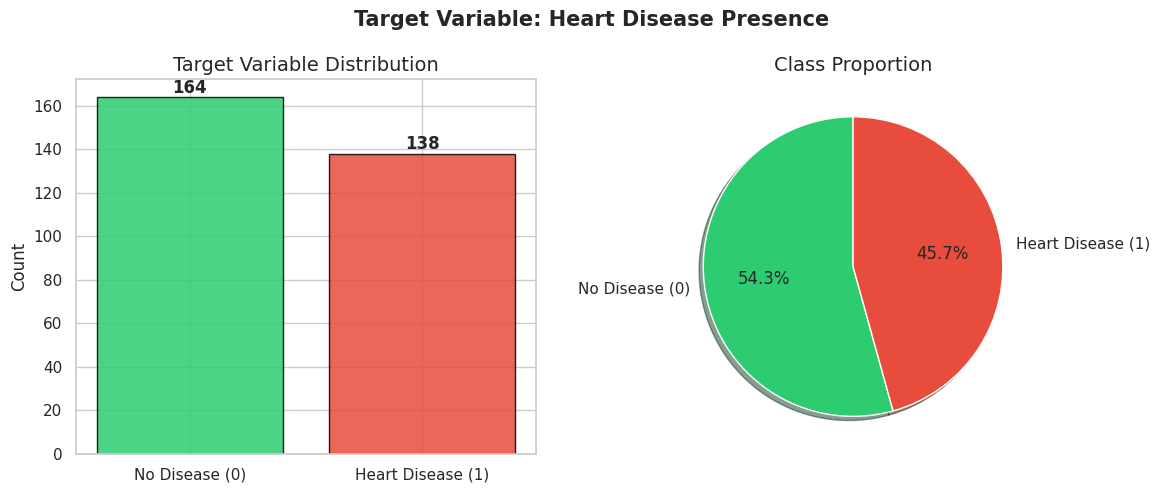

No Disease : 138 (45.7%)
Disease    : 164 (54.3%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['target'].value_counts()
labels = ['No Disease (0)', 'Heart Disease (1)']
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(labels, counts.values, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_title('Target Variable Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90, shadow=True)
axes[1].set_title('Class Proportion')

plt.suptitle('Target Variable: Heart Disease Presence', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'No Disease : {counts[0]} ({counts[0]/len(df)*100:.1f}%)')
print(f'Disease    : {counts[1]} ({counts[1]/len(df)*100:.1f}%)')

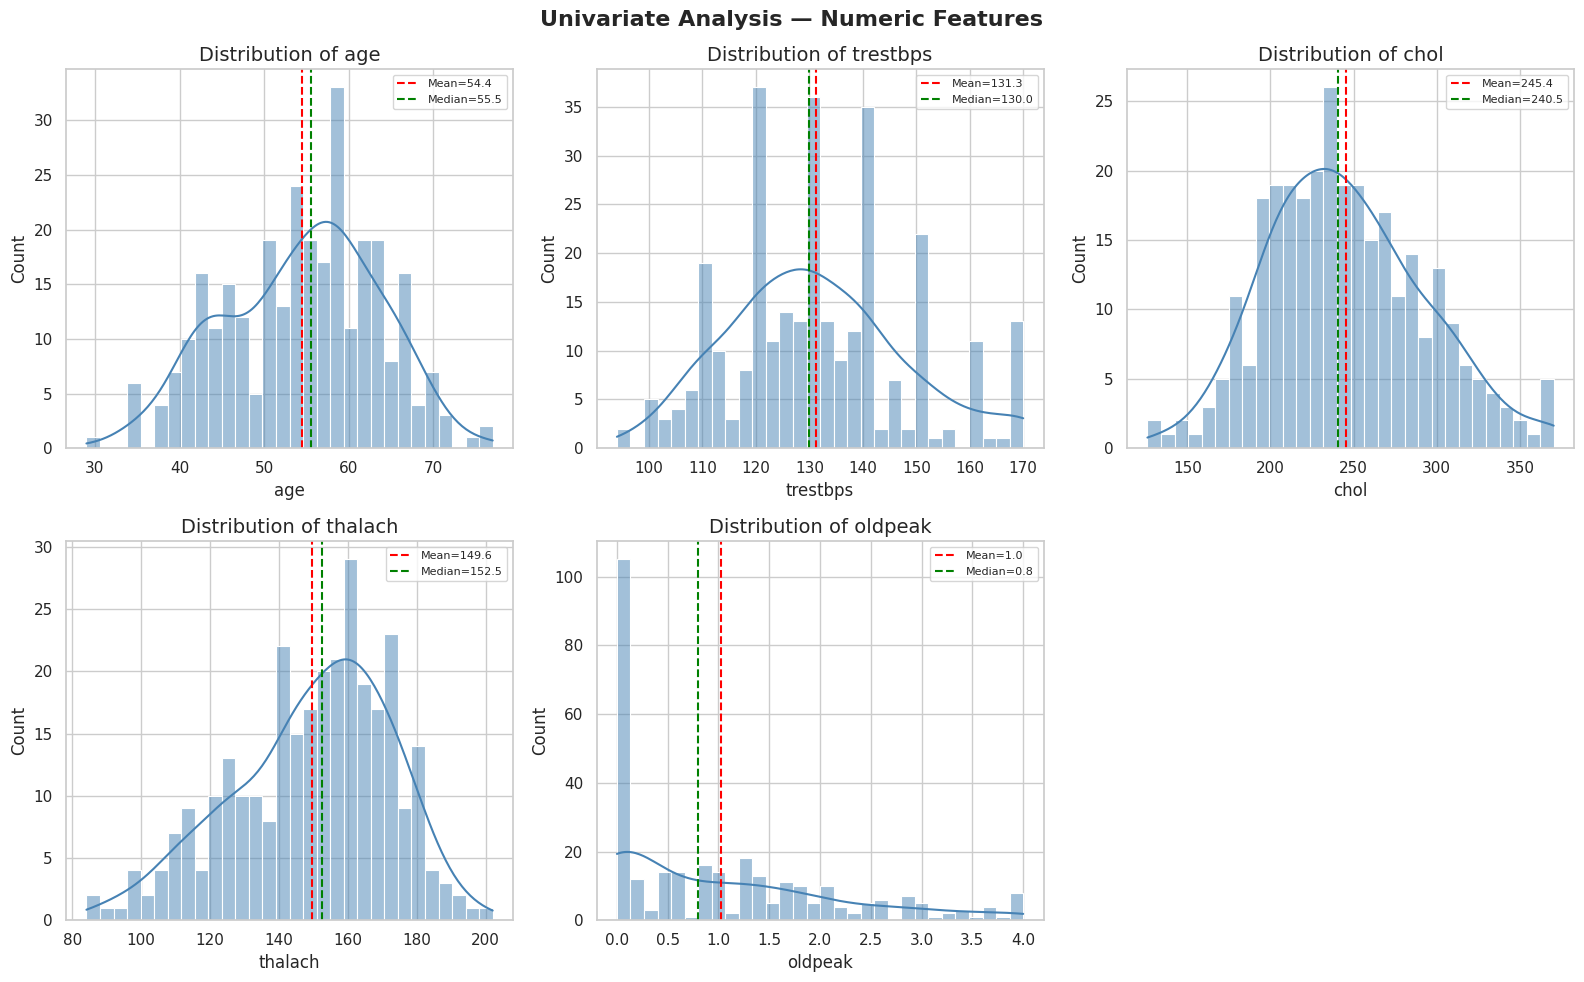

In [ ]:
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', bins=30)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].axvline(df[col].mean(),   color='red',   linestyle='--', label=f'Mean={df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median={df[col].median():.1f}')
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Univariate Analysis — Numeric Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

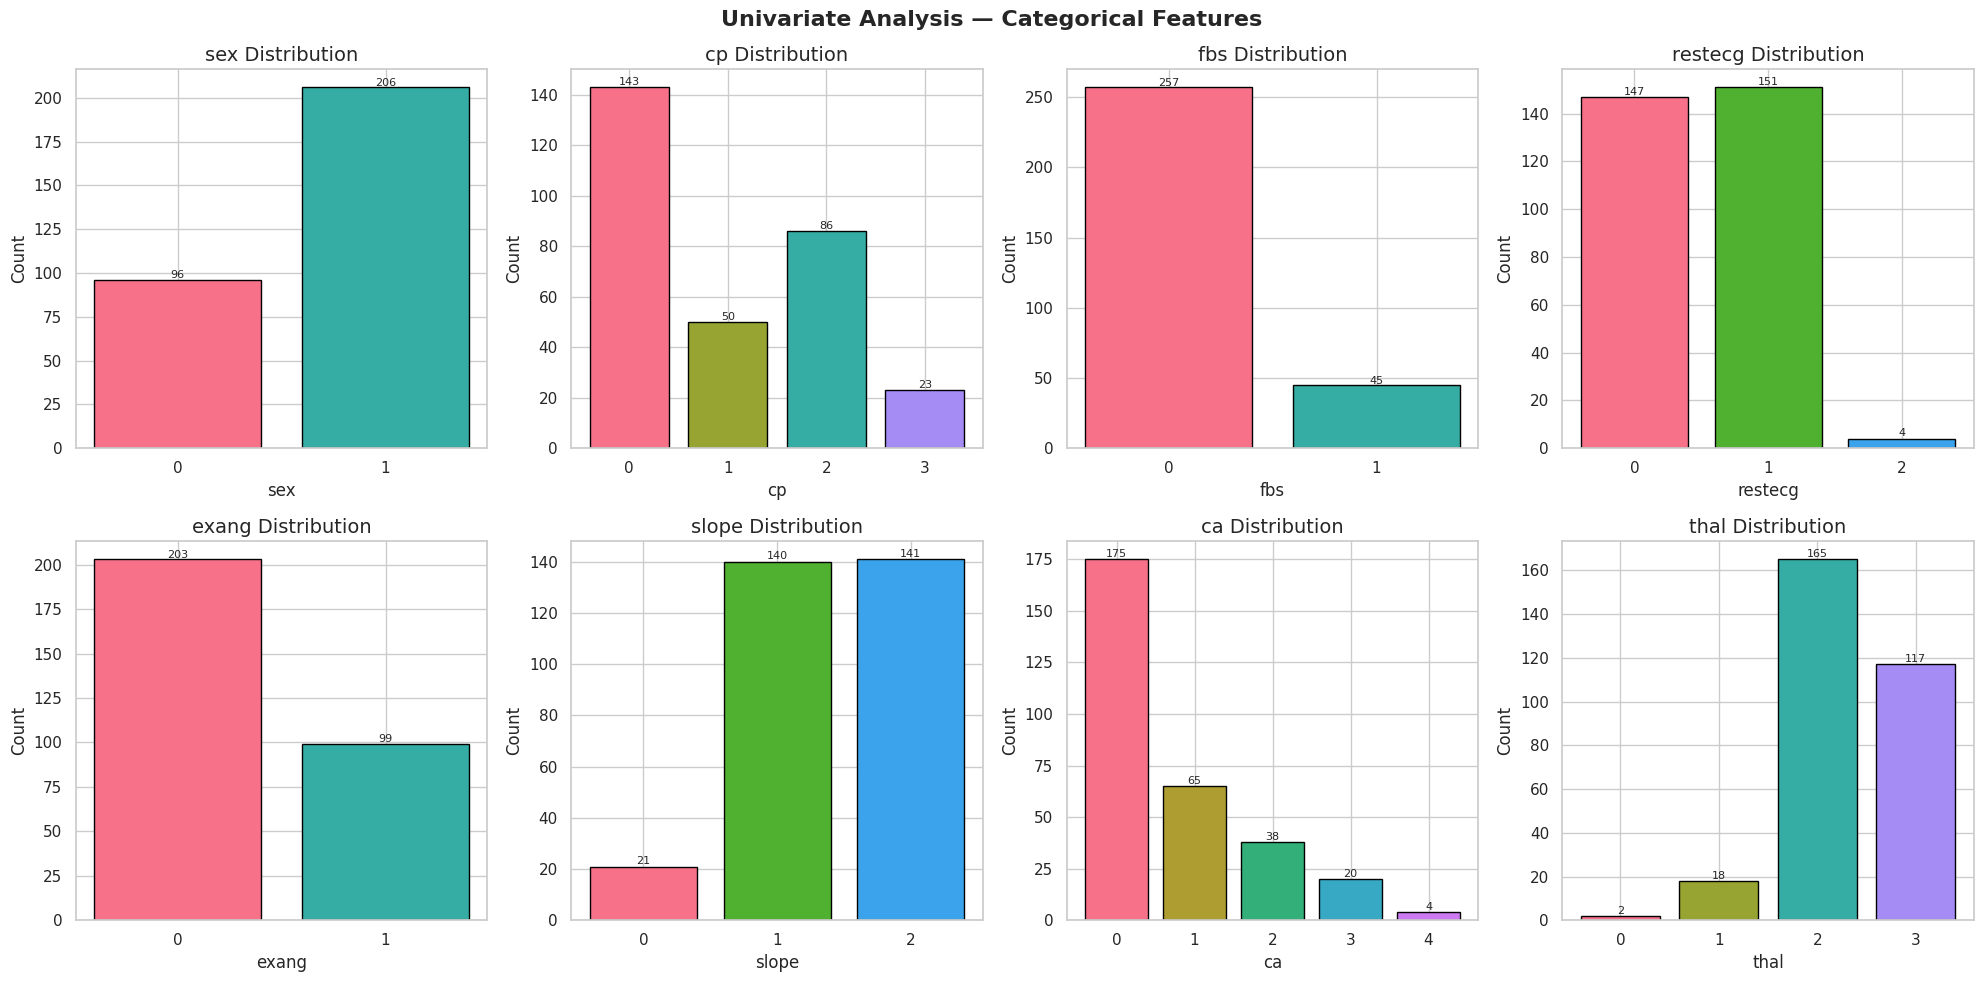

In [ ]:
cat_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    vc = df[col].value_counts().sort_index()
    axes[i].bar(vc.index.astype(str), vc.values,
                color=sns.color_palette('husl', len(vc)), edgecolor='black')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    for j, v in enumerate(vc.values):
        axes[i].text(j, v + 1, str(v), ha='center', fontsize=8)

plt.suptitle('Univariate Analysis — Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

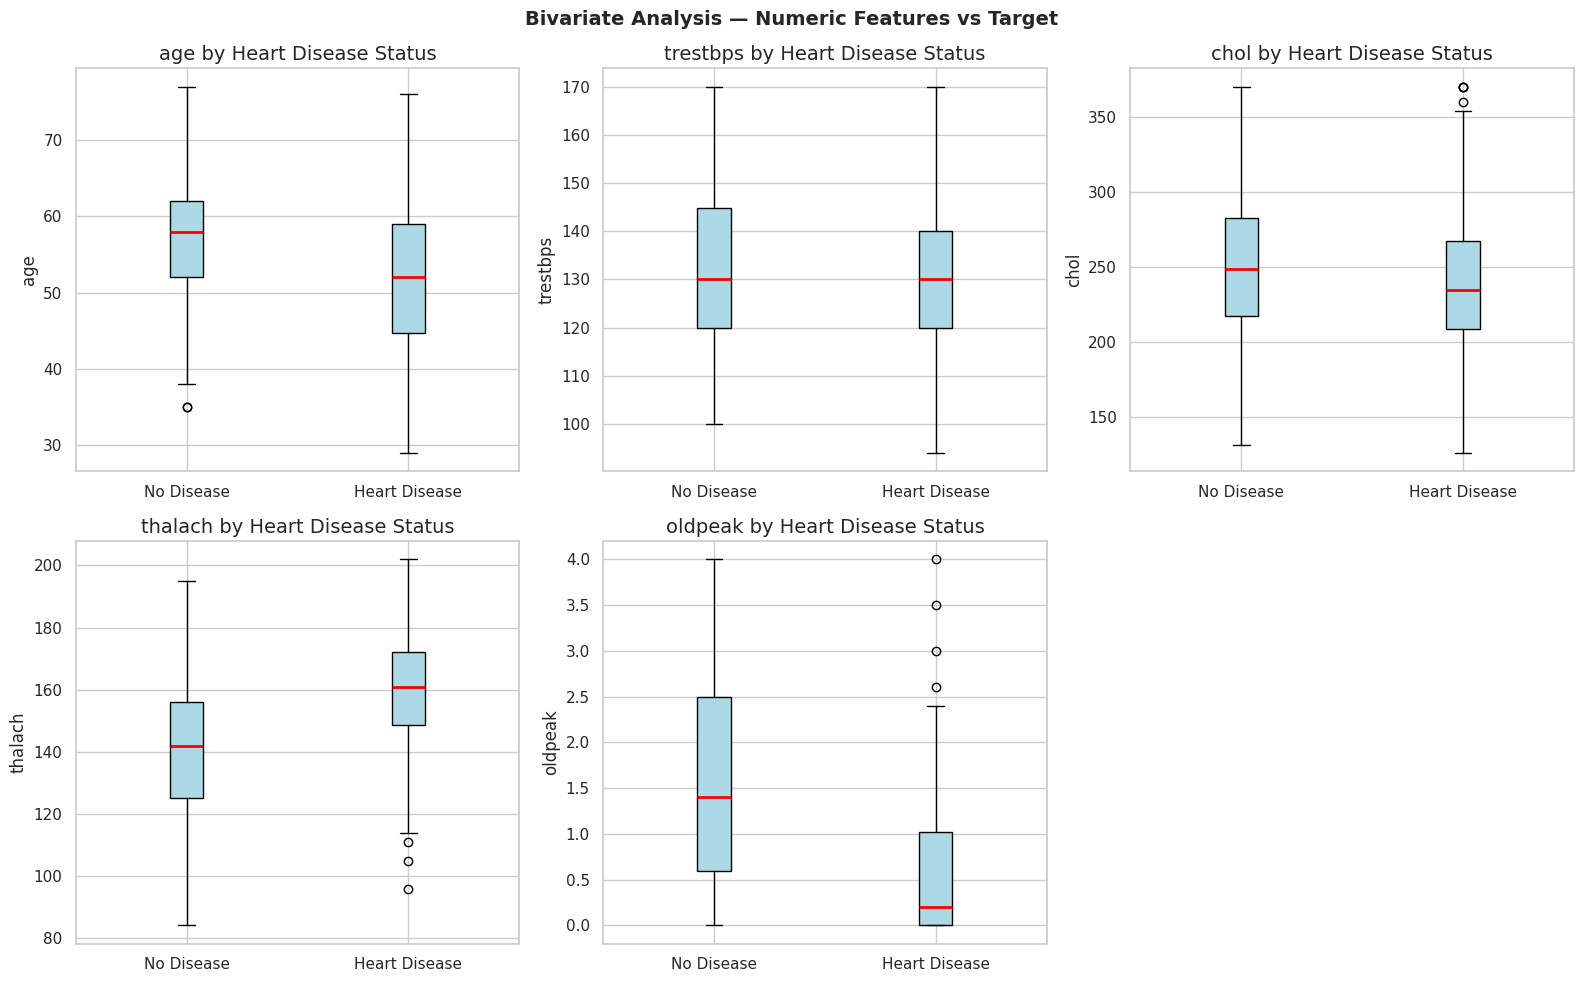

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    data_0 = df[df['target'] == 0][col]
    data_1 = df[df['target'] == 1][col]
    axes[i].boxplot([data_0, data_1],
                    labels=['No Disease', 'Heart Disease'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col} by Heart Disease Status')
    axes[i].set_ylabel(col)

axes[-1].axis('off')
plt.suptitle('Bivariate Analysis — Numeric Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

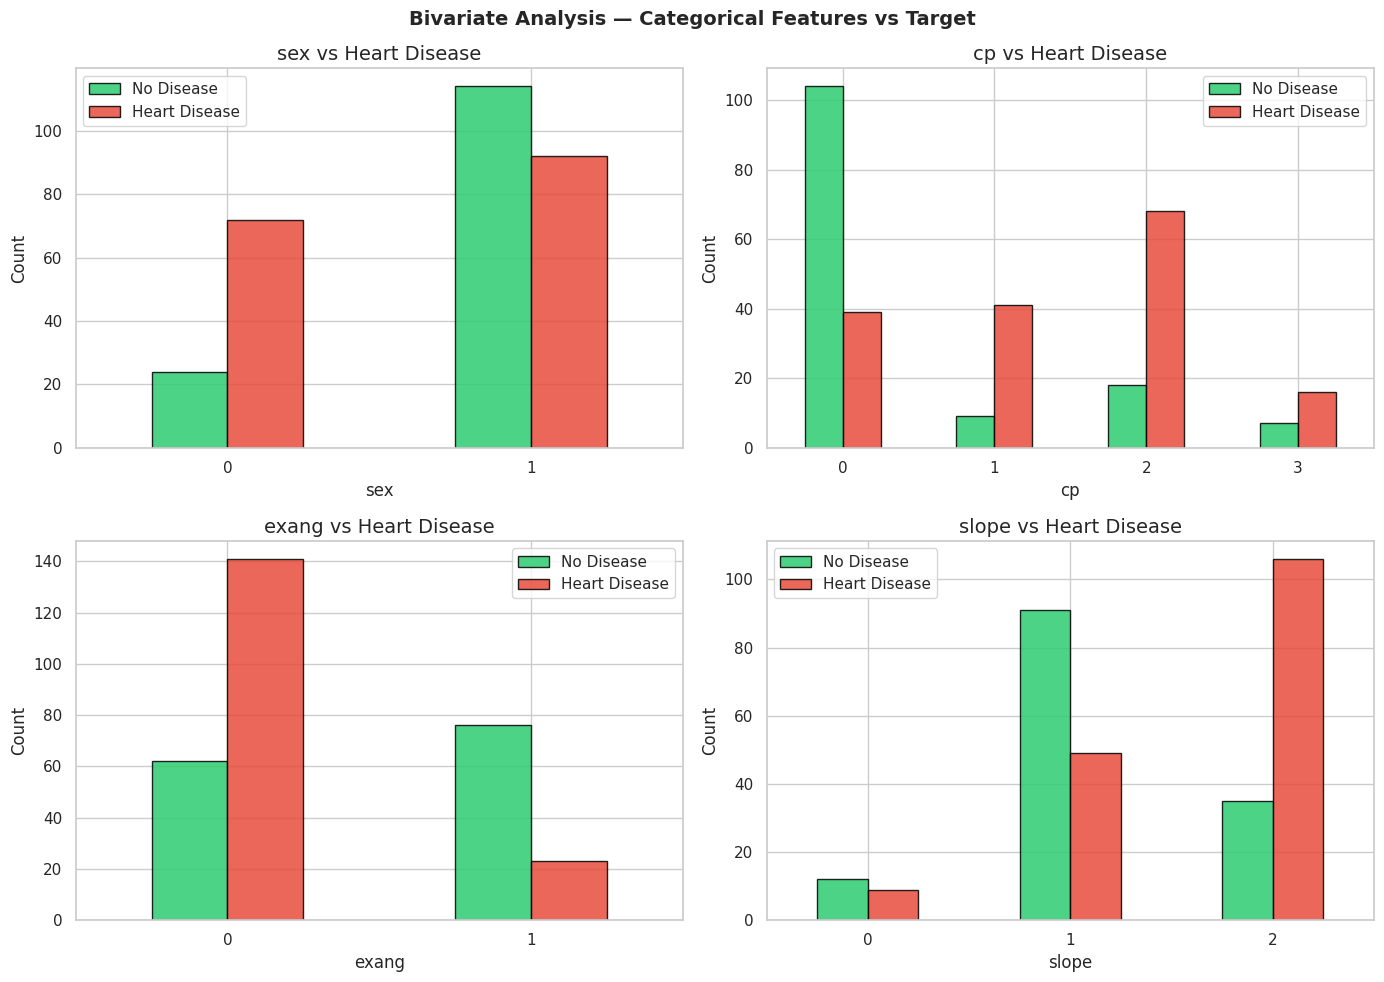

In [ ]:
cat_bivariate = ['sex', 'cp', 'exang', 'slope']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_bivariate):
    cross = pd.crosstab(df[col], df['target'])
    cross.plot(kind='bar', ax=axes[i],
               color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.85)
    axes[i].set_title(f'{col} vs Heart Disease')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(['No Disease', 'Heart Disease'])
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Bivariate Analysis — Categorical Features vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

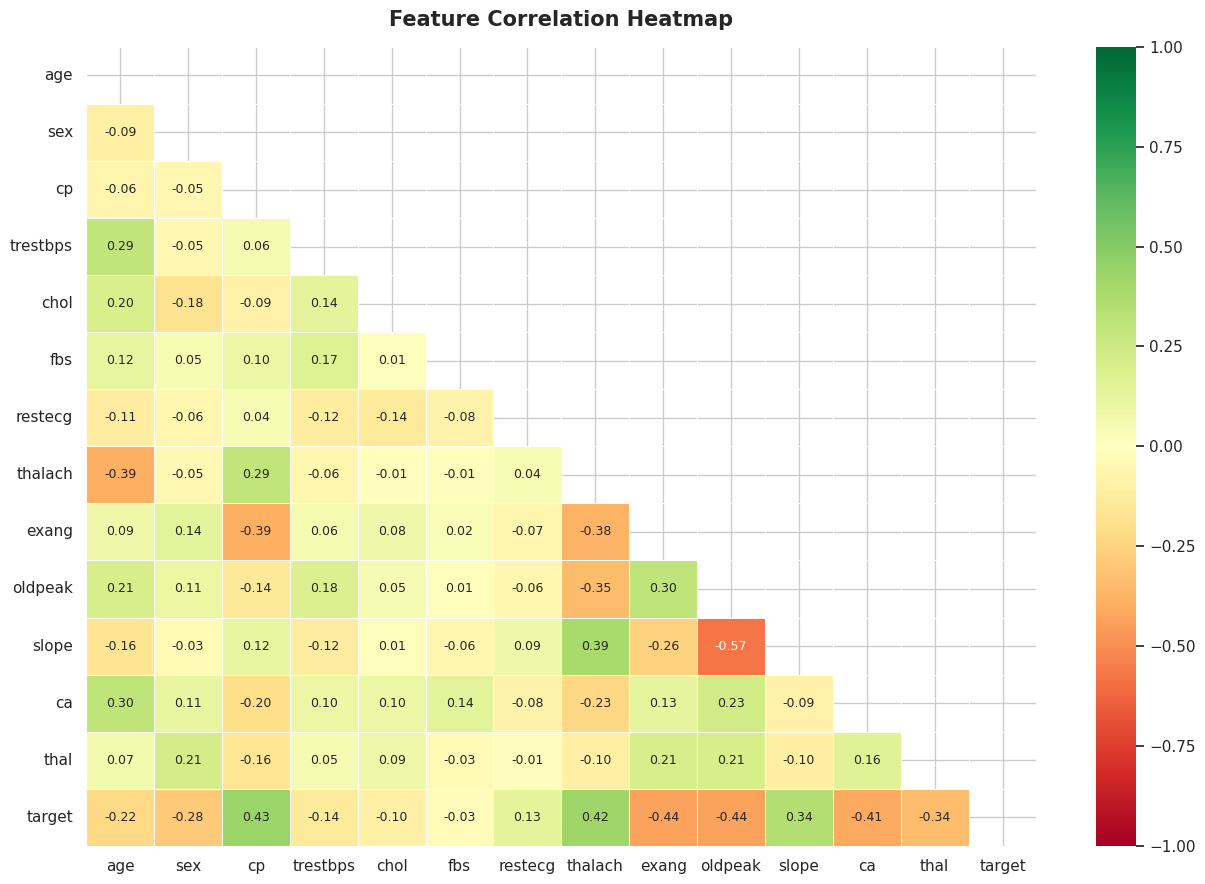


Top correlations with target:
exang       0.436
oldpeak     0.435
cp          0.432
thalach     0.420
ca          0.409
slope       0.344
thal        0.343
sex         0.284
age         0.221
trestbps    0.140
restecg     0.135
chol        0.100
fbs         0.027
Name: target, dtype: float64


In [ ]:
plt.figure(figsize=(13, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            center=0, annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('\nTop correlations with target:')
print(corr['target'].drop('target').abs().sort_values(ascending=False).round(3))

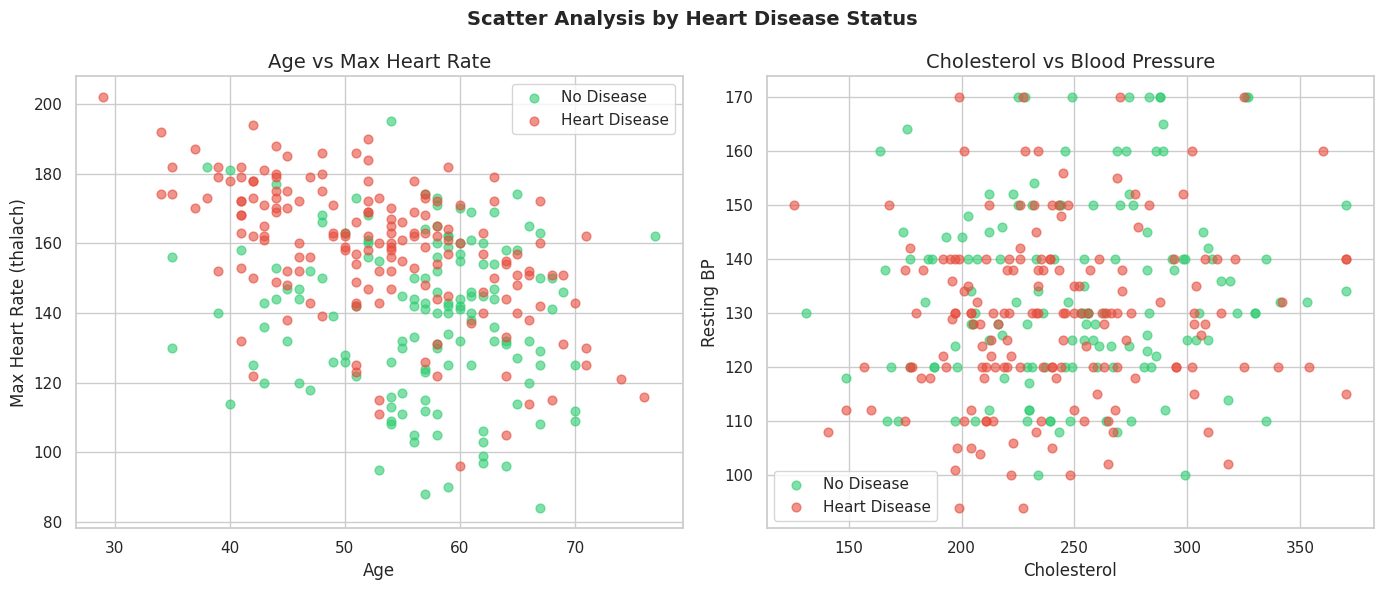

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for t, color, label in [(0,'#2ecc71','No Disease'), (1,'#e74c3c','Heart Disease')]:
    mask = df['target'] == t
    axes[0].scatter(df.loc[mask,'age'], df.loc[mask,'thalach'],
                    c=color, label=label, alpha=0.6, s=40)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Max Heart Rate (thalach)')
axes[0].set_title('Age vs Max Heart Rate')
axes[0].legend()

for t, color, label in [(0,'#2ecc71','No Disease'), (1,'#e74c3c','Heart Disease')]:
    mask = df['target'] == t
    axes[1].scatter(df.loc[mask,'chol'], df.loc[mask,'trestbps'],
                    c=color, label=label, alpha=0.6, s=40)
axes[1].set_xlabel('Cholesterol')
axes[1].set_ylabel('Resting BP')
axes[1].set_title('Cholesterol vs Blood Pressure')
axes[1].legend()

plt.suptitle('Scatter Analysis by Heart Disease Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

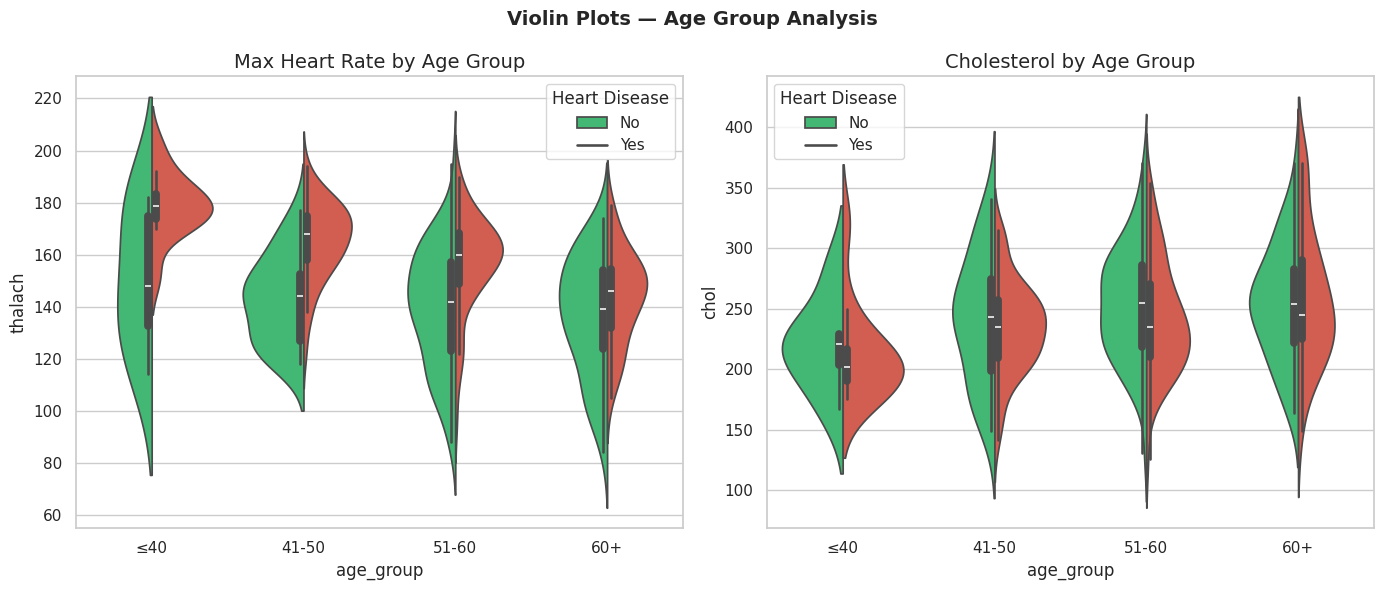

In [ ]:
df['age_group'] = pd.cut(df['age'], bins=[20, 40, 50, 60, 100],
                          labels=['≤40', '41-50', '51-60', '60+'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(x='age_group', y='thalach', hue='target', data=df,
               split=True, palette={0:'#2ecc71', 1:'#e74c3c'}, ax=axes[0])
axes[0].set_title('Max Heart Rate by Age Group')
axes[0].legend(title='Heart Disease', labels=['No','Yes'])

sns.violinplot(x='age_group', y='chol', hue='target', data=df,
               split=True, palette={0:'#2ecc71', 1:'#e74c3c'}, ax=axes[1])
axes[1].set_title('Cholesterol by Age Group')
axes[1].legend(title='Heart Disease', labels=['No','Yes'])

plt.suptitle('Violin Plots — Age Group Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

df = df.drop(columns=['age_group'])

In [ ]:
# New Feature 1: Age to Heart Rate Ratio
df['age_hr_ratio'] = df['age'] / (df['thalach'] + 1)
print('age_hr_ratio   : age divided by max heart rate')

# New Feature 2: Hypertension Flag
df['hypertension'] = (df['trestbps'] > 140).astype(int)
print('hypertension   : 1 if resting BP > 140 mmHg')

# New Feature 3: High Cholesterol Flag
df['high_chol'] = (df['chol'] > 240).astype(int)
print(' high_chol      : 1 if cholesterol > 240 mg/dl')

# New Feature 4: Composite Risk Score
df['risk_score'] = (
    df['exang'] * 2 +
    (df['oldpeak'] > 2).astype(int) * 2 +
    df['hypertension'] +
    df['high_chol'] +
    (df['age'] > 55).astype(int)
)
print('risk_score     : composite clinical risk indicator')

print(f'\nDataset now has {df.shape[1]} columns')
df[['age_hr_ratio','hypertension','high_chol','risk_score','target']].head()

age_hr_ratio   : age divided by max heart rate
hypertension   : 1 if resting BP > 140 mmHg
 high_chol      : 1 if cholesterol > 240 mg/dl
risk_score     : composite clinical risk indicator

Dataset now has 18 columns


,age_hr_ratio,hypertension,high_chol,risk_score,target
0,0.307692,0,0,0,0
1,0.339744,0,0,4,0
2,0.555556,1,0,6,0
3,0.376543,1,0,2,0
4,0.579439,0,1,2,0


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif, RFE

X_all = df.drop(columns=['target'])
y_all = df['target']

# --- Filter Method: ANOVA F-Score ---
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_all, y_all)
filter_scores = pd.Series(selector.scores_, index=X_all.columns).sort_values(ascending=False)

# --- Wrapper Method: RFE ---
scaler_rfe = StandardScaler()
X_scaled_all = scaler_rfe.fit_transform(X_all)
rfe = RFE(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), n_features_to_select=10)
rfe.fit(X_scaled_all, y_all)
rfe_selected = X_all.columns[rfe.support_].tolist()

# --- Embedded Method: Random Forest Importance ---
rf_embed = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_embed.fit(X_all, y_all)
rf_importance = pd.Series(rf_embed.feature_importances_, index=X_all.columns).sort_values(ascending=False)

print('Filter  (Top 10):', filter_scores.head(10).index.tolist())
print('Wrapper (RFE)   :', rfe_selected)
print('Embedded(Top 10):', rf_importance.head(10).index.tolist())

Filter  (Top 10): ['risk_score', 'exang', 'oldpeak', 'cp', 'thalach', 'ca', 'age_hr_ratio', 'slope', 'thal', 'sex']
Wrapper (RFE)   : ['sex', 'cp', 'trestbps', 'thalach', 'oldpeak', 'slope', 'ca', 'thal', 'age_hr_ratio', 'risk_score']
Embedded(Top 10): ['cp', 'risk_score', 'thal', 'ca', 'thalach', 'age_hr_ratio', 'oldpeak', 'chol', 'age', 'trestbps']


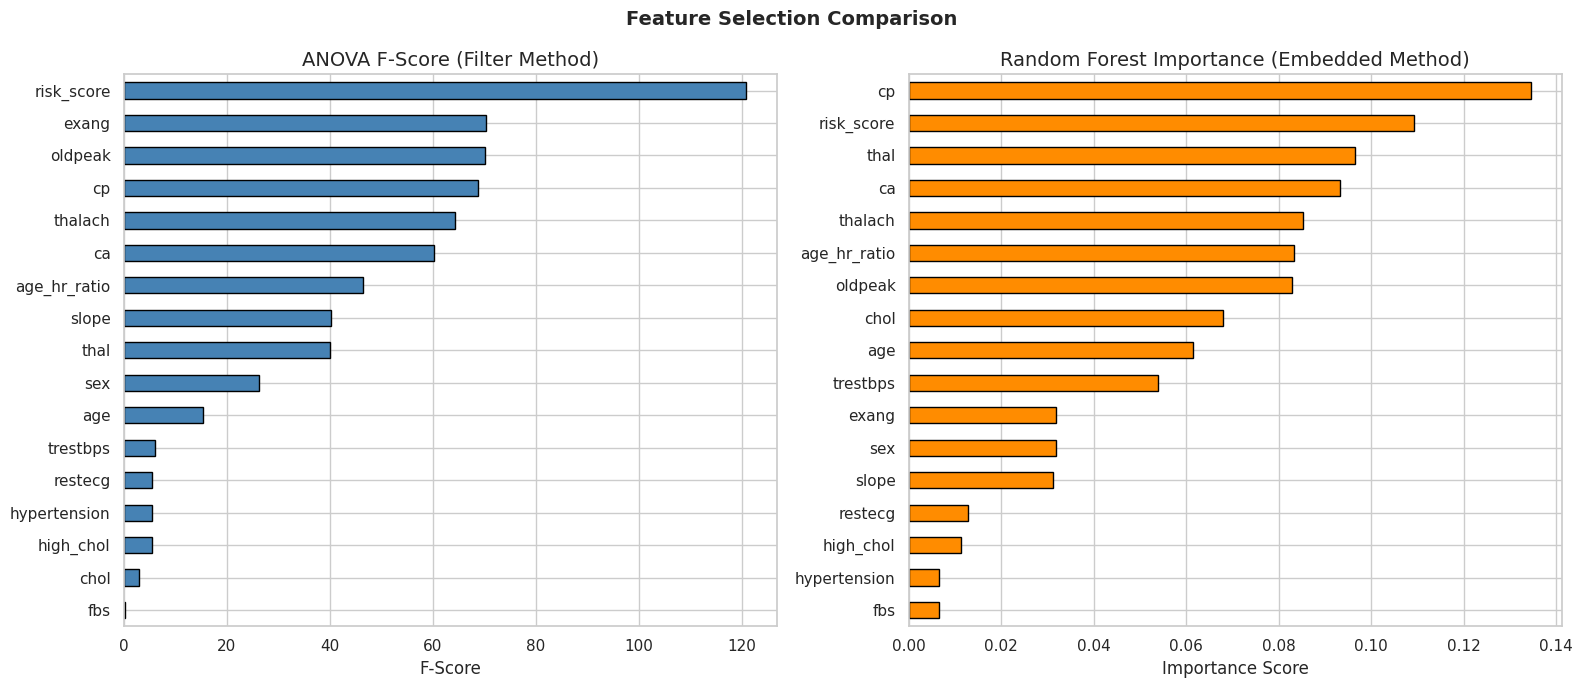

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

filter_scores.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('ANOVA F-Score (Filter Method)')
axes[0].set_xlabel('F-Score')
axes[0].invert_yaxis()

rf_importance.plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Random Forest Importance (Embedded Method)')
axes[1].set_xlabel('Importance Score')
axes[1].invert_yaxis()

plt.suptitle('Feature Selection Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
selected_features = [
    'age','sex','cp','trestbps','chol','thalach',
    'exang','oldpeak','slope','ca','thal',
    'age_hr_ratio','risk_score'
]

X = df[selected_features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train : {X_train.shape} | Test : {X_test.shape}')
print(f'Train target → {dict(y_train.value_counts())}')
print(f'Test  target → {dict(y_test.value_counts())}')

Train : (241, 13) | Test : (61, 13)
Train target → {1: np.int64(131), 0: np.int64(110)}
Test  target → {1: np.int64(33), 0: np.int64(28)}


In [ ]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Train model and return performance metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:,1] if hasattr(model,'predict_proba') else None
    cv     = cross_val_score(model, X_tr, y_tr, cv=5, scoring='accuracy')
    return {
        'Model'      : name,
        'Accuracy'   : accuracy_score(y_te, y_pred),
        'Precision'  : precision_score(y_te, y_pred),
        'Recall'     : recall_score(y_te, y_pred),
        'F1'         : f1_score(y_te, y_pred),
        'ROC-AUC'    : roc_auc_score(y_te, y_prob) if y_prob is not None else np.nan,
        'CV Mean'    : cv.mean(),
        'CV Std'     : cv.std(),
    }, model

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree'       : DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting'   : GradientBoostingClassifier(random_state=RANDOM_STATE),
    'KNN'                 : KNeighborsClassifier(),
    'SVM'                 : SVC(probability=True, random_state=RANDOM_STATE),
}

all_results   = []
trained_models = {}

print(f'{"Model":<25} | {"Acc":>6} | {"Prec":>6} | {"Rec":>6} | {"F1":>6} | {"AUC":>6}')
print('-' * 65)
for name, model in models.items():
    res, trained = evaluate_model(name, model, X_train_s, X_test_s, y_train, y_test)
    all_results.append(res)
    trained_models[name] = trained
    print(f'{name:<25} | {res["Accuracy"]:>6.3f} | {res["Precision"]:>6.3f} | {res["Recall"]:>6.3f} | {res["F1"]:>6.3f} | {res["ROC-AUC"]:>6.3f}')

results_df = pd.DataFrame(all_results).set_index('Model').round(4)
results_df

Model                     |    Acc |   Prec |    Rec |     F1 |    AUC
-----------------------------------------------------------------
Logistic Regression       |  0.803 |  0.839 |  0.788 |  0.812 |  0.893
Decision Tree             |  0.738 |  0.774 |  0.727 |  0.750 |  0.739
Random Forest             |  0.787 |  0.833 |  0.758 |  0.794 |  0.848
Gradient Boosting         |  0.787 |  0.794 |  0.818 |  0.806 |  0.846
KNN                       |  0.787 |  0.812 |  0.788 |  0.800 |  0.866
SVM                       |  0.787 |  0.794 |  0.818 |  0.806 |  0.859


,Accuracy,Precision,Recall,F1,ROC-AUC,CV Mean,CV Std
Model,,,,,,,
Logistic Regression,0.8033,0.8387,0.7879,0.8125,0.8929,0.8340,0.0187
Decision Tree,0.7377,0.7742,0.7273,0.7500,0.7386,0.7306,0.0487
Random Forest,0.7869,0.8333,0.7576,0.7937,0.8485,0.8173,0.0281
Gradient Boosting,0.7869,0.7941,0.8182,0.8060,0.8463,0.7595,0.0574
KNN,0.7869,0.8125,0.7879,0.8000,0.8658,0.8094,0.0287
SVM,0.7869,0.7941,0.8182,0.8060,0.8593,0.8173,0.0248


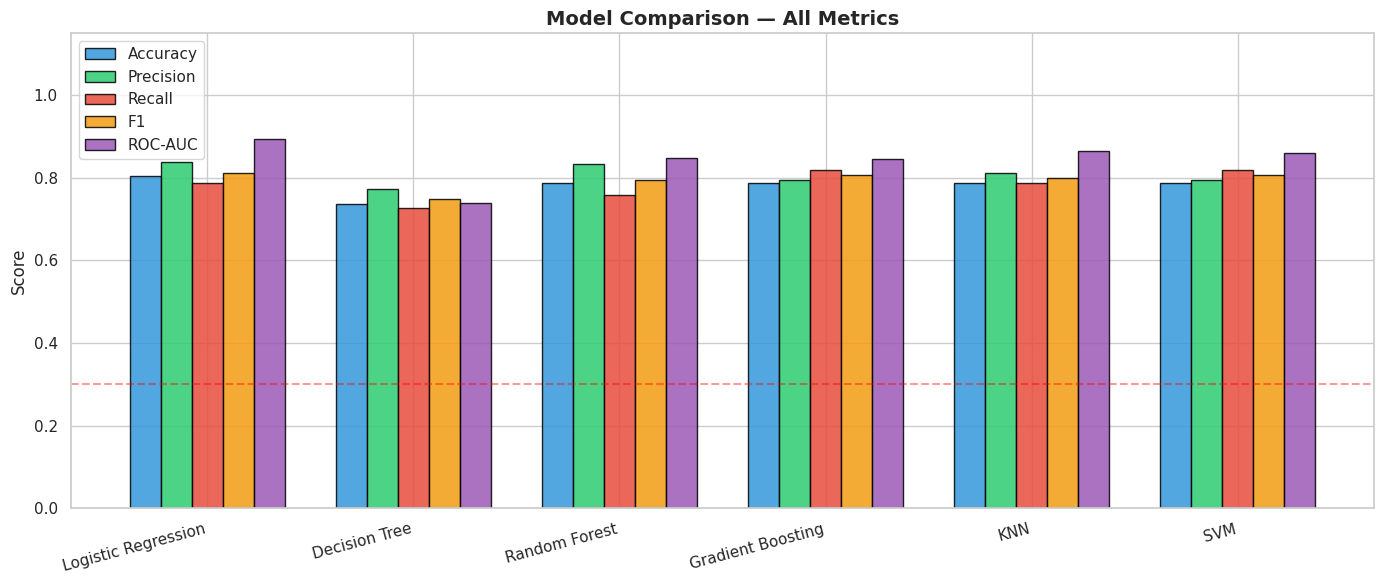

In [ ]:
metrics = ['Accuracy','Precision','Recall','F1','ROC-AUC']
x      = np.arange(len(results_df))
width  = 0.15
colors = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i*width, results_df[metric], width=width,
           label=metric, color=color, alpha=0.85, edgecolor='black')

ax.set_xticks(x + 2*width)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.legend()
ax.axhline(0.3, color='red', linestyle='--', alpha=0.4, label='Min 0.3 threshold')
plt.tight_layout()
plt.show()

In [26]:
# What is parameter tuning?
# It is the process of finding the best configuration (hyperparameters)
# for a model. Default settings rarely give the best results.
# GridSearchCV tries every combination and uses cross-validation
# to find the settings that generalize best to unseen data.

param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2'],
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid = param_grid,
    scoring    = 'f1',
    cv         = cv5,
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train_s, y_train)

print(f'\nBest Parameters : {grid_search.best_params_}')
print(f'Best CV F1 Score: {grid_search.best_score_:.4f}')
best_rf = grid_search.best_estimator_

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Parameters : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best CV F1 Score: 0.8583


In [ ]:
y_pred_final = best_rf.predict(X_test_s)
y_prob_final = best_rf.predict_proba(X_test_s)[:,1]

print('=' * 55)
print('FINAL MODEL — Tuned Random Forest')
print('=' * 55)
print(f'Accuracy  : {accuracy_score(y_test, y_pred_final):.4f}')
print(f'Precision : {precision_score(y_test, y_pred_final):.4f}   (≥ 0.3 required)')
print(f'Recall    : {recall_score(y_test, y_pred_final):.4f}   (≥ 0.3 required)')
print(f'F1-Score  : {f1_score(y_test, y_pred_final):.4f}')
print(f'ROC-AUC   : {roc_auc_score(y_test, y_prob_final):.4f}')
print()
print(classification_report(y_test, y_pred_final,
      target_names=['No Disease','Heart Disease']))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Disease','Heart Disease'],
            yticklabels=['No Disease','Heart Disease'],
            linewidths=2, linecolor='white',
            annot_kws={'size':16,'weight':'bold'})
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual',    fontsize=12)
axes[0].set_title('Confusion Matrix — Tuned Random Forest', fontweight='bold')

# ROC Curves
for name, model in trained_models.items():
    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X_test_s)[:,1]
        fpr, tpr, _ = roc_curve(y_test, probs)
        auc = roc_auc_score(y_test, probs)
        axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=1.5)

fpr_t, tpr_t, _ = roc_curve(y_test, y_prob_final)
axes[1].plot(fpr_t, tpr_t, 'k--',
             label=f'Tuned RF (AUC={roc_auc_score(y_test,y_prob_final):.3f})',
             linewidth=2.5)
axes[1].plot([0,1],[0,1],'r--', alpha=0.4, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Models', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# What is validation and why is it important?
# Validation measures how well a model generalises to unseen data.
# Without it a model may overfit — memorising training data but
# failing on new patients. K-Fold CV gives a reliable estimate
# by training and testing on different data splits k times.

cv_scores = cross_val_score(best_rf, X_train_s, y_train, cv=5, scoring='f1')
print(f'5-Fold CV F1 Scores : {cv_scores.round(4)}')
print(f'Mean CV F1          : {cv_scores.mean():.4f}')
print(f'Std  CV F1          : {cv_scores.std():.4f}')

In [ ]:
joblib.dump(best_rf,           '/content/models/heart_disease_model.pkl')
joblib.dump(scaler,            '/content/models/scaler.pkl')
joblib.dump(selected_features, '/content/models/feature_names.pkl')

print(' heart_disease_model.pkl saved')
print('scaler.pkl saved')
print(' feature_names.pkl saved')

# Verify reload works
m2 = joblib.load('/content/models/heart_disease_model.pkl')
s2 = joblib.load('/content/models/scaler.pkl')
test_pred = m2.predict(s2.transform(X_test.head(3)))
print(f'\nReload test predictions: {test_pred} ')